In [6]:
import pandas as pd






In [7]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.shape

(541909, 8)

In [9]:
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.duplicated().sum()



np.int64(5268)

In [13]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [14]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [15]:
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [16]:
df["CustomerID"].isnull().sum()

np.int64(135080)

In [17]:
df["Description"].isnull().sum()

np.int64(1454)

In [18]:
df = df.dropna(subset=["CustomerID"])

In [19]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()


np.int64(0)

In [22]:
(df["Quantity"] < 0).sum()

np.int64(8872)

In [23]:
df = df[df["Quantity"] > 0]


In [24]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [25]:
(df["Quantity"] == 0).sum()

np.int64(0)

In [26]:
(df["UnitPrice"] <= 0).sum()

np.int64(40)

In [27]:
df["UnitPrice"].min()

np.float64(0.0)

In [28]:
df = df[df["UnitPrice"] > 0]

In [29]:
(df["UnitPrice"] <= 0).sum()

np.int64(0)

In [30]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [31]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [32]:
df.shape

(392692, 9)

In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [35]:
df["Revenue"].sum()



np.float64(8887208.894000001)

In [36]:
df["CustomerID"].nunique()

4338

In [37]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [38]:
df["Country"].nunique()

37

In [39]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [40]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [41]:
rfm.shape

(4338, 3)

In [42]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [43]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [44]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [45]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score
CustomerID,,,,,
12346.0,326,1,77183.60,1,1
12347.0,2,7,4310.00,5,5
12348.0,75,4,1797.24,2,4
12349.0,19,1,1757.55,4,1
12350.0,310,1,334.40,1,1


In [46]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [47]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [48]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str)
    + rfm["F_Score"].astype(int).astype(str)
    + rfm["M_Score"].astype(int).astype(str)
)

In [49]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [50]:
rfm_ml = rfm[["Recency", "Frequency", "Monetary"]].copy()

In [51]:
rfm_ml.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_ml)

In [53]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_ml.index
)

In [54]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [55]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

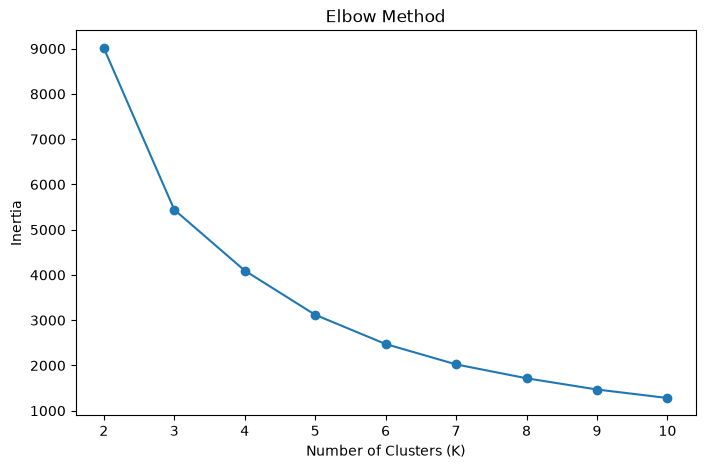

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [57]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{3: 0.5942233320872992, 4: 0.6162275299061803, 5: 0.6165002474679847}

In [58]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [59]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

In [60]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [61]:
cluster_summary["Customer_Count"] = rfm["Cluster"].value_counts().sort_index()

cluster_summary

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.70,3.68,1353.63,3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,127187.96,13
3,15.50,22.33,12690.50,204


In [62]:
segment_names = {
    0: "Regular Customers",
    1: "At-Risk / Inactive Customers",
    2: "VIP High-Value Customers",
    3: "Loyal High-Value Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [63]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,3,Loyal High-Value Customers
12347.0,2,7,4310.00,5,5,5,555,0,Regular Customers
12348.0,75,4,1797.24,2,4,4,244,0,Regular Customers
12349.0,19,1,1757.55,4,1,4,414,0,Regular Customers
12350.0,310,1,334.40,1,1,2,112,1,At-Risk / Inactive Customers


In [64]:
rfm["Segment"].value_counts()

Segment
Regular Customers               3054
At-Risk / Inactive Customers    1067
Loyal High-Value Customers       204
VIP High-Value Customers          13
Name: count, dtype: int64

In [65]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
Regular Customers               3054
At-Risk / Inactive Customers    1067
Loyal High-Value Customers       204
VIP High-Value Customers          13
Name: count, dtype: int64

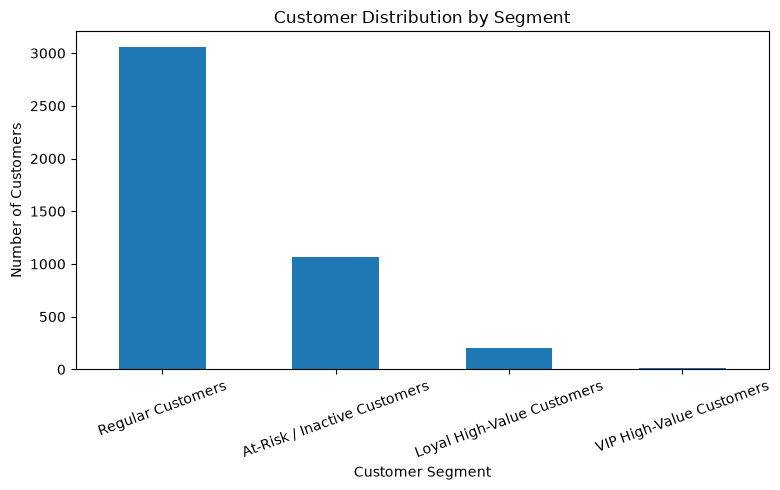

In [66]:
plt.figure(figsize=(8, 5))

segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [67]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue

Segment
Regular Customers               4133971.703
Loyal High-Value Customers      2588862.080
VIP High-Value Customers        1653443.470
At-Risk / Inactive Customers     510931.641
Name: Monetary, dtype: float64

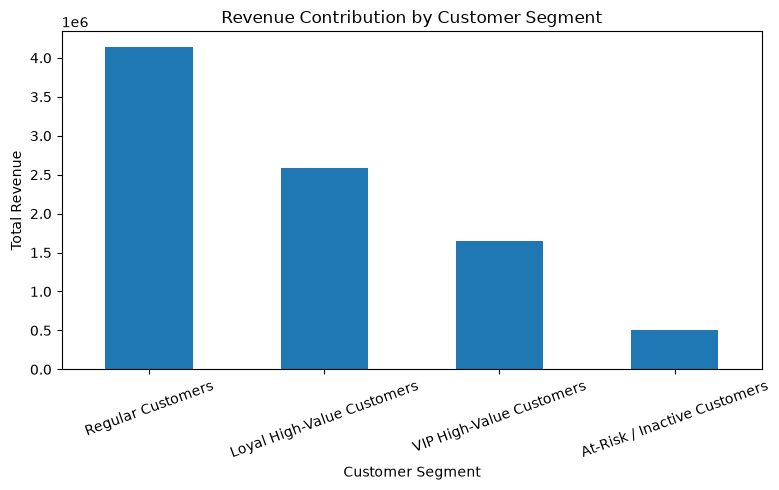

In [68]:
plt.figure(figsize=(8, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [69]:
segment_revenue_pct = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

segment_revenue_pct

Segment
Regular Customers               46.52
Loyal High-Value Customers      29.13
VIP High-Value Customers        18.60
At-Risk / Inactive Customers     5.75
Name: Monetary, dtype: float64

In [70]:
segment_profile = rfm.groupby("Segment").agg(
    Customer_Count=("Recency", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_profile


,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At-Risk / Inactive Customers,1067,248.08,1.55,478.85
Loyal High-Value Customers,204,15.50,22.33,12690.50
Regular Customers,3054,43.70,3.68,1353.63
VIP High-Value Customers,13,7.38,82.54,127187.96


In [71]:
segment_profile["Revenue_Share_%"] = (
    rfm.groupby("Segment")["Monetary"].sum()
    / rfm["Monetary"].sum()
    * 100
).round(2)

segment_profile

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue_Share_%
Segment,,,,,
At-Risk / Inactive Customers,1067,248.08,1.55,478.85,5.75
Loyal High-Value Customers,204,15.50,22.33,12690.50,29.13
Regular Customers,3054,43.70,3.68,1353.63,46.52
VIP High-Value Customers,13,7.38,82.54,127187.96,18.60


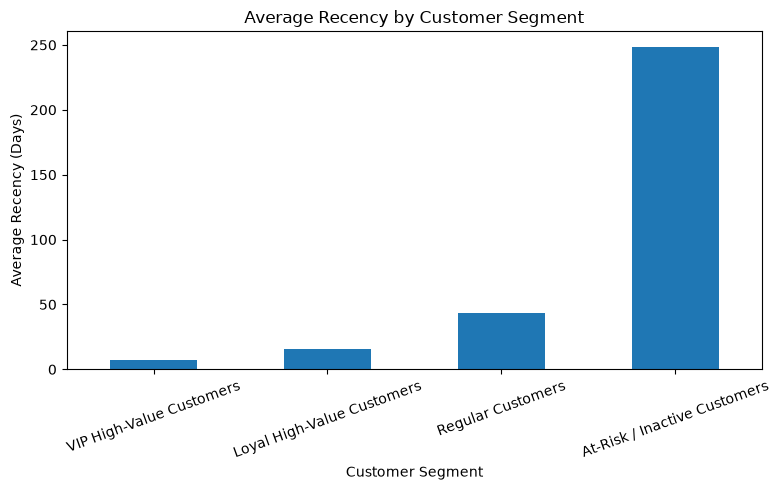

In [72]:
plt.figure(figsize=(8, 5))

segment_profile["Avg_Recency"].sort_values().plot(kind="bar")

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

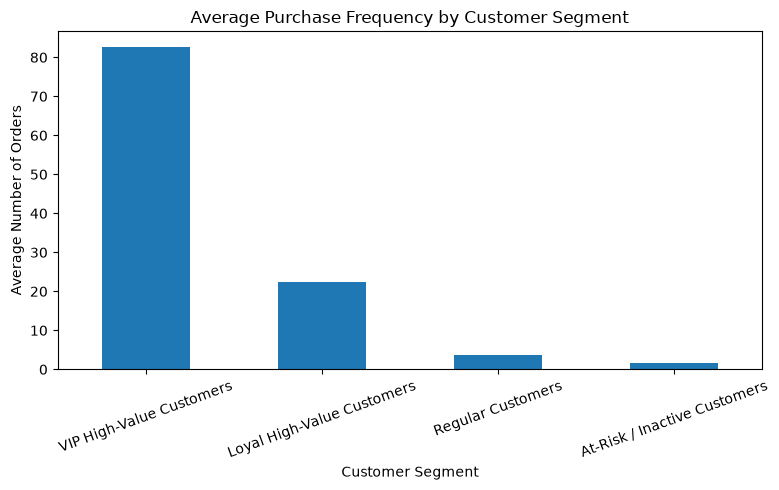

In [73]:
plt.figure(figsize=(8, 5))

segment_profile["Avg_Frequency"].sort_values(ascending=False).plot(kind="bar")

plt.title("Average Purchase Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

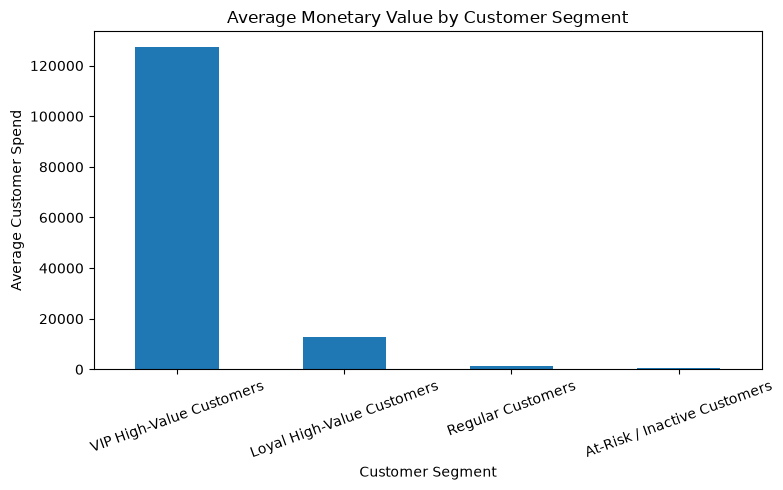

In [74]:
plt.figure(figsize=(8, 5))

segment_profile["Avg_Monetary"].sort_values(ascending=False).plot(kind="bar")

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Customer Spend")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [75]:
rfm_heatmap = segment_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
].copy()

rfm_heatmap


,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,
At-Risk / Inactive Customers,248.08,1.55,478.85
Loyal High-Value Customers,15.50,22.33,12690.50
Regular Customers,43.70,3.68,1353.63
VIP High-Value Customers,7.38,82.54,127187.96


In [76]:
 import seaborn as sns



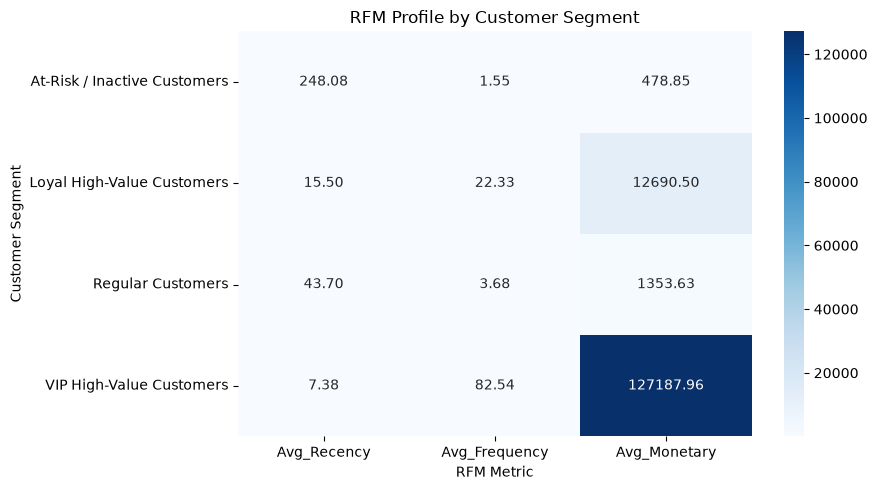

In [77]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    rfm_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("RFM Profile by Customer Segment")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [78]:
total_customers = rfm.shape[0]
total_revenue = rfm["Monetary"].sum()
avg_customer_spend = rfm["Monetary"].mean()

print("Total Customers:", total_customers)
print("Total Revenue:", round(total_revenue, 2))
print("Average Customer Spend:", round(avg_customer_spend, 2))
print("Number of Segments:", rfm["Segment"].nunique())



Total Customers: 4338
Total Revenue: 8887208.89
Average Customer Spend: 2048.69
Number of Segments: 4


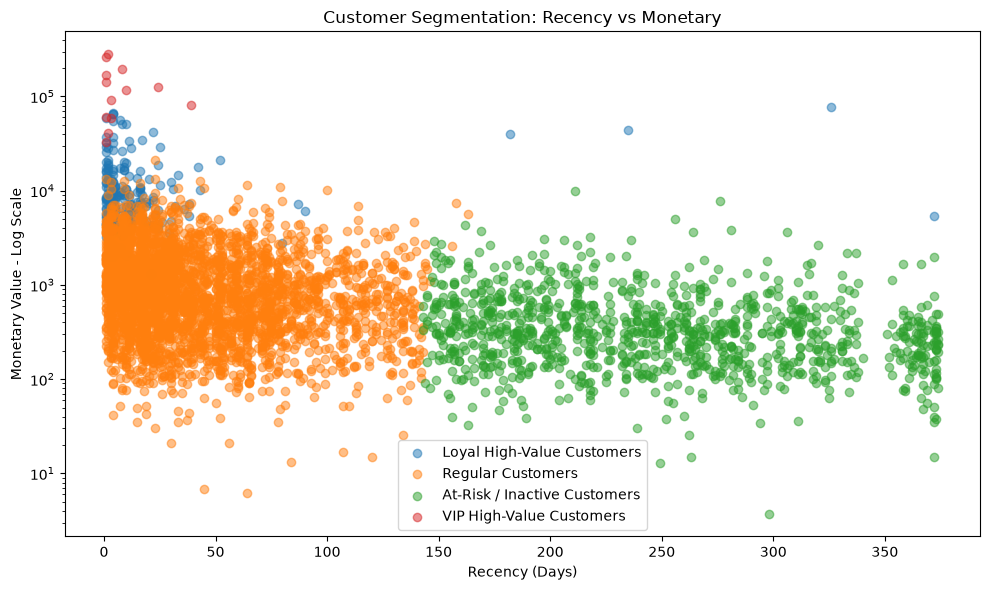

In [79]:
plt.figure(figsize=(10, 6))

for segment in rfm["Segment"].unique():
    segment_data = rfm[rfm["Segment"] == segment]

    plt.scatter(
        segment_data["Recency"],
        segment_data["Monetary"],
        label=segment,
        alpha=0.5
    )

plt.yscale("log")

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value - Log Scale")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
final_customer_data = rfm.reset_index()

final_customer_data.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
0,12346.0,326,1,77183.60,1,1,5,115,3,Loyal High-Value Customers
1,12347.0,2,7,4310.00,5,5,5,555,0,Regular Customers
2,12348.0,75,4,1797.24,2,4,4,244,0,Regular Customers
3,12349.0,19,1,1757.55,4,1,4,414,0,Regular Customers
4,12350.0,310,1,334.40,1,1,2,112,1,At-Risk / Inactive Customers


In [81]:
final_customer_data.to_csv(
    "../data/customer_segmentation.csv",
    index=False
)

In [82]:
final_customer_data.shape

(4338, 10)

In [83]:
final_customer_data.columns


Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score', 'Cluster', 'Segment'],
      dtype='str')

In [84]:
import os

os.path.exists("../data/customer_segmentation.csv")

True